In [1]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.4 MB/s eta 0:00:00


In [2]:
from google_play_scraper import reviews, Sort
import csv
import pandas as pd

# Ganti APP_ID sesuai aplikasi yang mau kamu scrape
# Contoh Mobile Legends:
# APP_ID = 'com.mobile.legends'
APP_ID = 'semarangkota.sidnok'

result, continuation_token = reviews(
    APP_ID,
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=1000,
    filter_score_with=None
)

filename = 'ulasan_google_play.csv'

with open(filename, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(
        f,
        fieldnames=['userName', 'score', 'at', 'content']
    )
    writer.writeheader()

    for review in result:
        writer.writerow({
            'userName': review.get('userName'),
            'score': review.get('score'),
            'at': review.get('at'),
            'content': review.get('content')
        })

print(f"Berhasil menyimpan {len(result)} ulasan ke '{filename}'")

# Tampilkan data di Colab
df = pd.read_csv(filename)
df.head()

Berhasil menyimpan 656 ulasan ke 'ulasan_google_play.csv'


,userName,score,at,content
0,Luhur Adi Prasmono,1,2026-05-05 09:43:39,"aplikasi ribet untuk dijalankan, tidak efisien"
1,Wawan,1,2026-05-05 00:24:43,daftar sdh 2 minggu masih belum dikirim passwo...
2,Rvan Utama,4,2026-05-04 01:30:45,Banyak yang komentar minus mungkin memang ada ...
3,Aris Ershi HP,3,2026-04-28 04:43:12,Menu e-ktp kok ga ada
4,Hendra Maulana,1,2026-04-13 01:31:15,"aplikasi ga jelas , kira kira habis berapa ang..."


In [3]:

import pandas as pd

df = pd.read_csv('ulasan_google_play.csv')

def label_sentimen(score):
    if score >= 4:
        return 'Positive'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['Sentimen'] = df['score'].apply(label_sentimen)

df.head()

,userName,score,at,content,Sentimen
0,Luhur Adi Prasmono,1,2026-05-05 09:43:39,"aplikasi ribet untuk dijalankan, tidak efisien",Negative
1,Wawan,1,2026-05-05 00:24:43,daftar sdh 2 minggu masih belum dikirim passwo...,Negative
2,Rvan Utama,4,2026-05-04 01:30:45,Banyak yang komentar minus mungkin memang ada ...,Positive
3,Aris Ershi HP,3,2026-04-28 04:43:12,Menu e-ktp kok ga ada,Neutral
4,Hendra Maulana,1,2026-04-13 01:31:15,"aplikasi ga jelas , kira kira habis berapa ang...",Negative


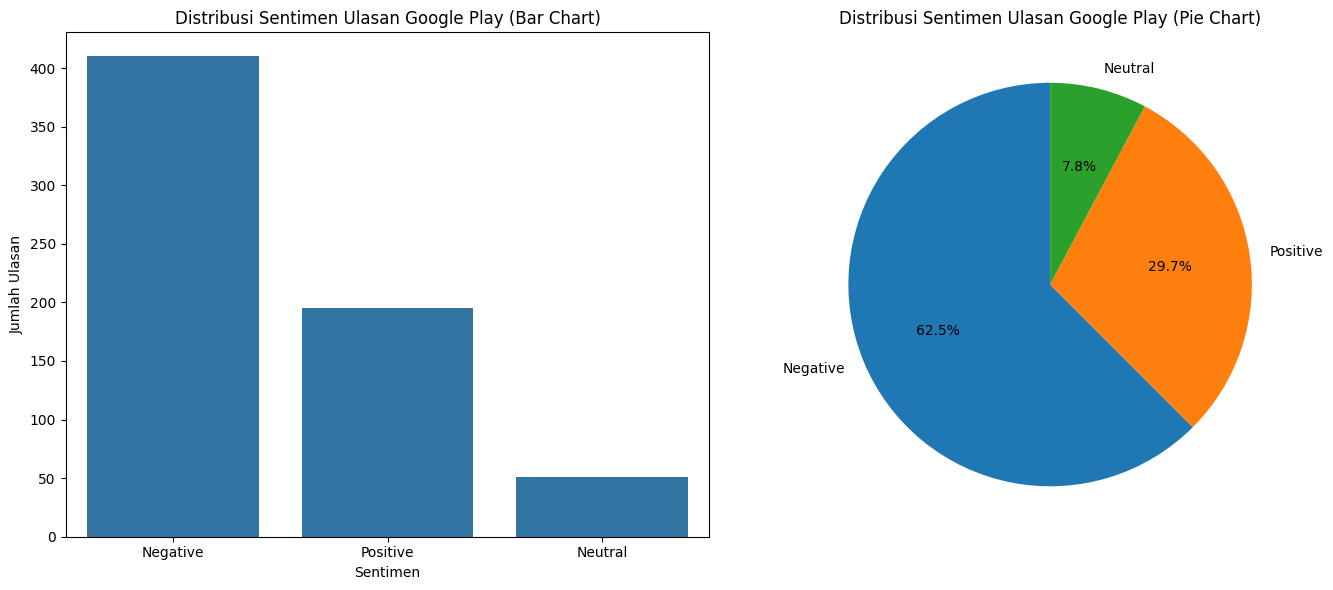

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung jumlah tiap sentimen
sentiment_counts = df['Sentimen'].value_counts()

# Buat figure dengan 2 chart berdampingan
plt.figure(figsize=(14, 6))

# Bar Chart
plt.subplot(1, 2, 1)
sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)
plt.title('Distribusi Sentimen Ulasan Google Play (Bar Chart)')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')

# Pie Chart
plt.subplot(1, 2, 2)
plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Distribusi Sentimen Ulasan Google Play (Pie Chart)')

# Rapikan layout
plt.tight_layout()

# Simpan gambar
plt.savefig('distribusi_sentimen_ulasan_google_play.png', dpi=300)

# Tampilkan gambar
plt.show()

In [9]:
readme_text = """# 📊 Scraper Ulasan Google Play Store

![Python](https://img.shields.io/badge/python-3670A0?style=for-the-badge&logo=python&logoColor=ffdd54)
![Google Colab](https://img.shields.io/badge/Colab-F9AB00?style=for-the-badge&logo=googlecolab&color=525252)

Project ini dibuat untuk mengambil data ulasan aplikasi dari Google Play Store menggunakan Python di Google Colab.

## 📱 Aplikasi yang Dianalisis

Aplikasi yang digunakan:

- **Nama aplikasi:** Aplikasi Pemerintahan
- **App ID:** id.go.kemensos.pelaporan

## 🛠️ Library yang Digunakan

- google-play-scraper
- pandas
- matplotlib
- seaborn

## 📂 Data yang Diambil

Data ulasan yang diambil dari Google Play Store meliputi:

- userName
- score
- at
- content
- Sentimen

## 📈 Metode Analisis Sentimen

Analisis sentimen dilakukan berdasarkan rating ulasan:

- **Positive (Positif):** Rating 4 sampai 5 😃
- **Neutral (Netral):** Rating 3 😐
- **Negative (Negatif):** Rating 1 sampai 2 😡

## 📁 Output File

Project ini menghasilkan file:

- ulasan_google_play.csv
- distribusi_sentimen_ulasan_google_play.png
- uts-big-data.ipynb

**Contoh Visualisasi Hasil Sentimen:**
![Distribusi Sentimen Ulasan](distribusi_sentimen_ulasan_google_play.png)

## 💡 Kesimpulan

Data ulasan Google Play Store berhasil diambil, disimpan dalam format CSV, dan divisualisasikan dalam bentuk bar chart serta pie chart.
"""

with open("README.md", "w", encoding="utf-8") as file:
    file.write(readme_text)

print("README.md berhasil dibuat!")

README.md berhasil dibuat!


In [10]:
from google.colab import files

files.download('ulasan_google_play.csv')
files.download('distribusi_sentimen_ulasan_google_play.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>